In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)

In [35]:
df = pd.read_csv("Crime_Data_from_2020_to_Present.csv")
#To dosplay the top 5 rows
df.head(5)

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,03/01/2020 12:00:00 AM,03/01/2020 12:00:00 AM,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,02/09/2020 12:00:00 AM,02/08/2020 12:00:00 AM,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 12:00:00 AM,11/04/2020 12:00:00 AM,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,05/10/2023 12:00:00 AM,03/10/2020 12:00:00 AM,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,220614831,08/18/2022 12:00:00 AM,08/17/2020 12:00:00 AM,1200,6,Hollywood,666,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,1900 TRANSIENT,NaN,34.0944,-118.3277


In [36]:
df.tail(5)

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
947770,242106032,02/20/2024 12:00:00 AM,02/17/2024 12:00:00 AM,2330,21,Topanga,2103,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,IC,Invest Cont,420.0,NaN,NaN,NaN,22700 NAPA ST,NaN,34.2260,-118.6214
947771,242004546,01/16/2024 12:00:00 AM,01/16/2024 12:00:00 AM,1510,20,Olympic,2013,2,624,BATTERY - SIMPLE ASSAULT,...,IC,Invest Cont,624.0,NaN,NaN,NaN,HOBART BL,3RD ST,34.0690,-118.3054
947772,240104953,01/15/2024 12:00:00 AM,01/15/2024 12:00:00 AM,100,1,Central,101,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),...,IC,Invest Cont,745.0,NaN,NaN,NaN,1300 W SUNSET BL,NaN,34.0685,-118.2460
947773,240309674,04/24/2024 12:00:00 AM,04/24/2024 12:00:00 AM,1500,3,Southwest,358,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,FLOWER ST,JEFFERSON BL,34.0215,-118.2868
947774,240900704,04/29/2024 12:00:00 AM,04/29/2024 12:00:00 AM,2020,9,Van Nuys,916,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",...,IC,Invest Cont,740.0,998.0,NaN,NaN,6800 HAZELTINE AV,NaN,34.1939,-118.4400


In [37]:
df.dtypes

DR_NO               int64
Date Rptd          object
DATE OCC           object
TIME OCC            int64
AREA                int64
AREA NAME          object
Rpt Dist No         int64
Part 1-2            int64
Crm Cd              int64
Crm Cd Desc        object
Mocodes            object
Vict Age            int64
Vict Sex           object
Vict Descent       object
Premis Cd         float64
Premis Desc        object
Weapon Used Cd    float64
Weapon Desc        object
Status             object
Status Desc        object
Crm Cd 1          float64
Crm Cd 2          float64
Crm Cd 3          float64
Crm Cd 4          float64
LOCATION           object
Cross Street       object
LAT               float64
LON               float64
dtype: object

In [38]:
df = df.drop(['DR_NO', 'Date Rptd', 'Rpt Dist No', 'Crm Cd 1', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'Part 1-2'], axis = 1)
df.head(5)

,DATE OCC,TIME OCC,AREA,AREA NAME,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,LOCATION,Cross Street,LAT,LON
0,03/01/2020 12:00:00 AM,2130,7,Wilshire,510,VEHICLE - STOLEN,NaN,0,M,O,101.0,STREET,NaN,NaN,AA,Adult Arrest,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,02/08/2020 12:00:00 AM,1800,1,Central,330,BURGLARY FROM VEHICLE,1822 1402 0344,47,M,O,128.0,BUS STOP/LAYOVER (ALSO QUERY 124),NaN,NaN,IC,Invest Cont,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,11/04/2020 12:00:00 AM,1700,3,Southwest,480,BIKE - STOLEN,0344 1251,19,X,X,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",NaN,NaN,IC,Invest Cont,1400 W 37TH ST,NaN,34.0210,-118.3002
3,03/10/2020 12:00:00 AM,2037,9,Van Nuys,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),0325 1501,19,M,O,405.0,CLOTHING STORE,NaN,NaN,IC,Invest Cont,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,08/17/2020 12:00:00 AM,1200,6,Hollywood,354,THEFT OF IDENTITY,1822 1501 0930 2004,28,M,H,102.0,SIDEWALK,NaN,NaN,IC,Invest Cont,1900 TRANSIENT,NaN,34.0944,-118.3277


In [63]:
df = df.rename(columns={"Crm Cd": "Crime Committed", "Crm Cd Desc": "Crime Code Descript", "Mocodes": "Modus Operandi", "Status" : "Crime Status", "AREA NAME" : "AREA_NAME"})
df.head(5)

,DATE OCC,TIME OCC,AREA,AREA_NAME,Crime Committed,Crime Code Descript,Modus Operandi,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premise Code Descript,Weapon Used Cd,Weapon Desc,Crime Status,Crime Status Descript,LOCATION,Cross Street,LAT,LON
91,06/30/2020 12:00:00 AM,1400,3,Southwest,626,INTIMATE PARTNER - SIMPLE ASSAULT,0913 2000 1814 0416 0446,25,F,B,501.0,SINGLE FAMILY DWELLING,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,VERMONT AV,43RD ST,34.0055,-118.2915
150,07/24/2020 12:00:00 AM,1500,10,West Valley,761,BRANDISH WEAPON,1202 1822 0334,59,F,H,102.0,SIDEWALK,500.0,UNKNOWN WEAPON/OTHER WEAPON,IC,Invest Cont,SHERMAN WY,ENCINO,34.2012,-118.5133
151,03/01/2020 12:00:00 AM,1200,10,West Valley,626,INTIMATE PARTNER - SIMPLE ASSAULT,2000 1813 0416,43,M,H,101.0,STREET,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AA,Adult Arrest,SHIRLEY,ROSCOE BL,34.2204,-118.5579
210,04/01/2020 12:00:00 AM,2300,13,Newton,210,ROBBERY,1309 1313 0342 0444 0302 0449 1218 1822,50,X,H,124.0,BUS STOP,102.0,HAND GUN,IC,Invest Cont,12TH ST,SAN PEDRO ST,34.0337,-118.2533
228,07/02/2020 12:00:00 AM,940,6,Hollywood,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0400 0416 0444 1822 1501,52,M,W,102.0,SIDEWALK,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AO,Adult Other,YUCCA ST,HIGHLAND AV,34.1032,-118.3387


In [74]:
df = df.rename(columns={"Crime Code Descript":"Crime_Code_Descript", "Status Desc": "Crime Status Descript", "Weapon Descript" : "Weapon Used Descript", "Premis Desc": "Premise Code Descript"})
df.head(5)

,DATE OCC,TIME OCC,AREA,AREA_NAME,Crime Committed,Crime_Code_Descript,Modus Operandi,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premise Code Descript,Weapon Used Cd,Weapon Desc,Crime Status,Crime Status Descript,LOCATION,Cross Street,LAT,LON
91,06/30/2020 12:00:00 AM,1400,3,Southwest,626,INTIMATE PARTNER - SIMPLE ASSAULT,0913 2000 1814 0416 0446,25,F,B,501.0,SINGLE FAMILY DWELLING,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,VERMONT AV,43RD ST,34.0055,-118.2915
150,07/24/2020 12:00:00 AM,1500,10,West Valley,761,BRANDISH WEAPON,1202 1822 0334,59,F,H,102.0,SIDEWALK,500.0,UNKNOWN WEAPON/OTHER WEAPON,IC,Invest Cont,SHERMAN WY,ENCINO,34.2012,-118.5133
151,03/01/2020 12:00:00 AM,1200,10,West Valley,626,INTIMATE PARTNER - SIMPLE ASSAULT,2000 1813 0416,43,M,H,101.0,STREET,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AA,Adult Arrest,SHIRLEY,ROSCOE BL,34.2204,-118.5579
210,04/01/2020 12:00:00 AM,2300,13,Newton,210,ROBBERY,1309 1313 0342 0444 0302 0449 1218 1822,50,X,H,124.0,BUS STOP,102.0,HAND GUN,IC,Invest Cont,12TH ST,SAN PEDRO ST,34.0337,-118.2533
228,07/02/2020 12:00:00 AM,940,6,Hollywood,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0400 0416 0444 1822 1501,52,M,W,102.0,SIDEWALK,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AO,Adult Other,YUCCA ST,HIGHLAND AV,34.1032,-118.3387


In [75]:
df.shape

(75012, 20)

In [76]:
duplicate_rows_df = df[df.duplicated()]
print("Number of duplicate rows: ", duplicate_rows_df.shape)

Number of duplicate rows:  (321, 20)


In [77]:
print(df.isnull().sum())

DATE OCC                 0
TIME OCC                 0
AREA                     0
AREA_NAME                0
Crime Committed          0
Crime_Code_Descript      0
Modus Operandi           0
Vict Age                 0
Vict Sex                 0
Vict Descent             0
Premis Cd                0
Premise Code Descript    0
Weapon Used Cd           0
Weapon Desc              0
Crime Status             0
Crime Status Descript    0
LOCATION                 0
Cross Street             0
LAT                      0
LON                      0
dtype: int64


In [78]:
df = df.dropna() # Dropping missing values.
df.shape

(75012, 20)

In [79]:
print(df.isnull().sum()) # After dropping missing values

DATE OCC                 0
TIME OCC                 0
AREA                     0
AREA_NAME                0
Crime Committed          0
Crime_Code_Descript      0
Modus Operandi           0
Vict Age                 0
Vict Sex                 0
Vict Descent             0
Premis Cd                0
Premise Code Descript    0
Weapon Used Cd           0
Weapon Desc              0
Crime Status             0
Crime Status Descript    0
LOCATION                 0
Cross Street             0
LAT                      0
LON                      0
dtype: int64


<Axes: xlabel='AREA'>

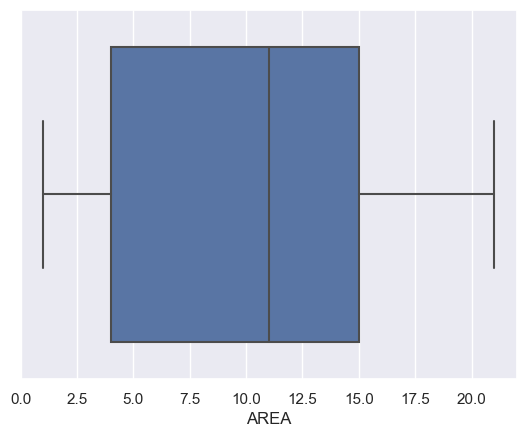

In [80]:
sns.boxplot(x=df['AREA'])

<Axes: xlabel='Crime Committed'>

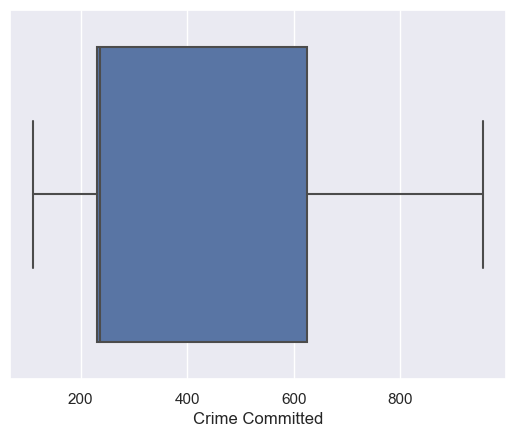

In [81]:
sns.boxplot(x=df['Crime Committed'])

Text(0.5, 0, 'AREA NAME')

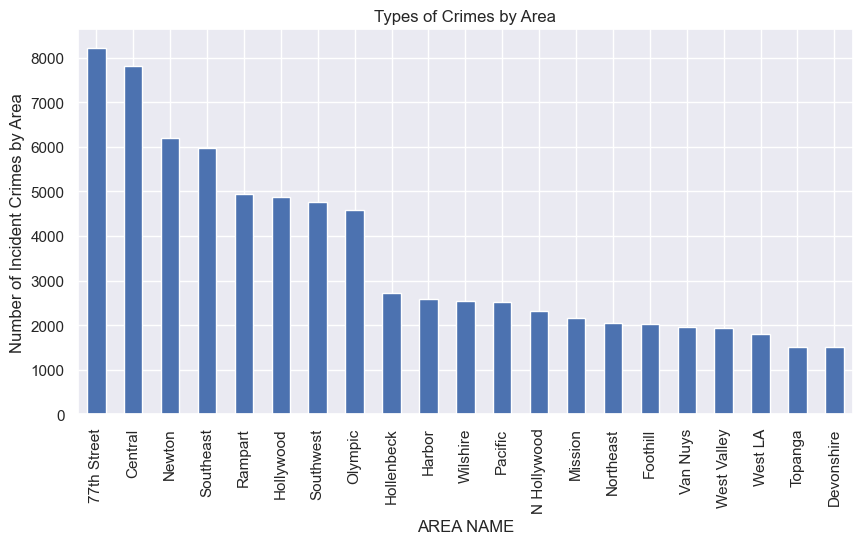

In [82]:
df.AREA_NAME.value_counts().nlargest(40).plot(kind='bar', figsize=(10,5))
plt.title("Types of Crimes by Area")
plt.ylabel('Number of Incident Crimes by Area')
plt.xlabel('AREA NAME')

Text(0.5, 0, 'CRIME KIND')

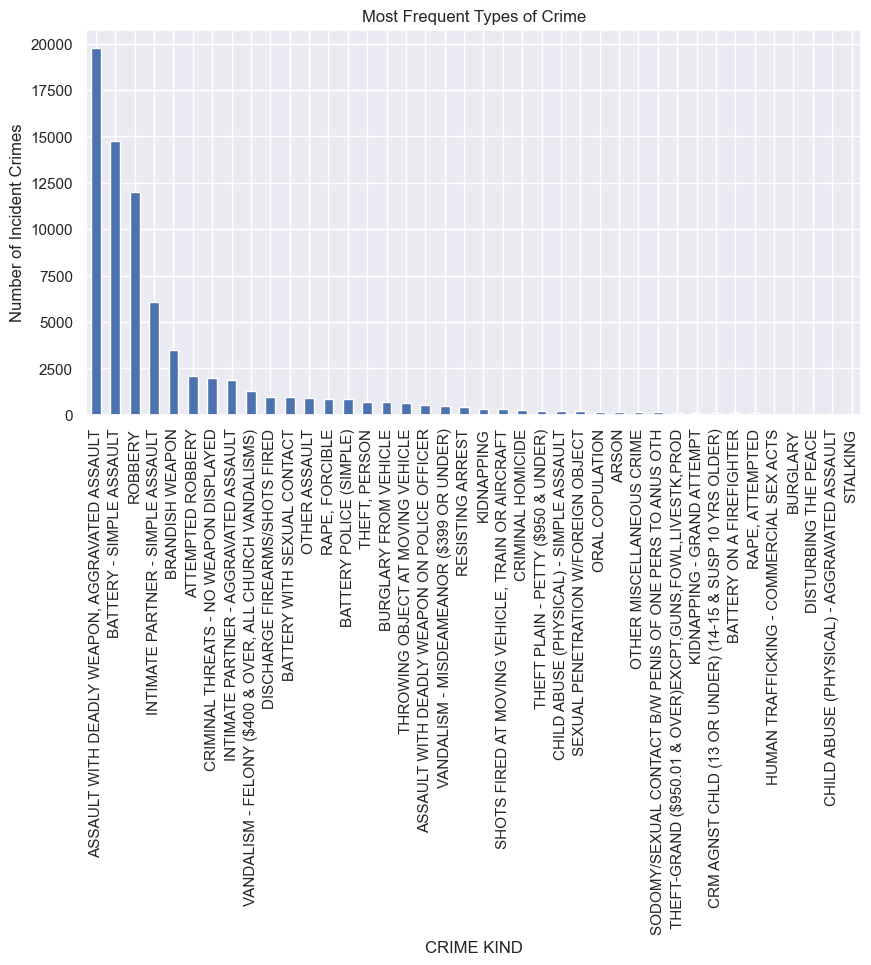

In [86]:
df.Crime_Code_Descript.value_counts().nlargest(40).plot(kind='bar', figsize=(10,5))
plt.title("Most Frequent Types of Crime")
plt.ylabel('Number of Incident Crimes')
plt.xlabel('CRIME KIND')

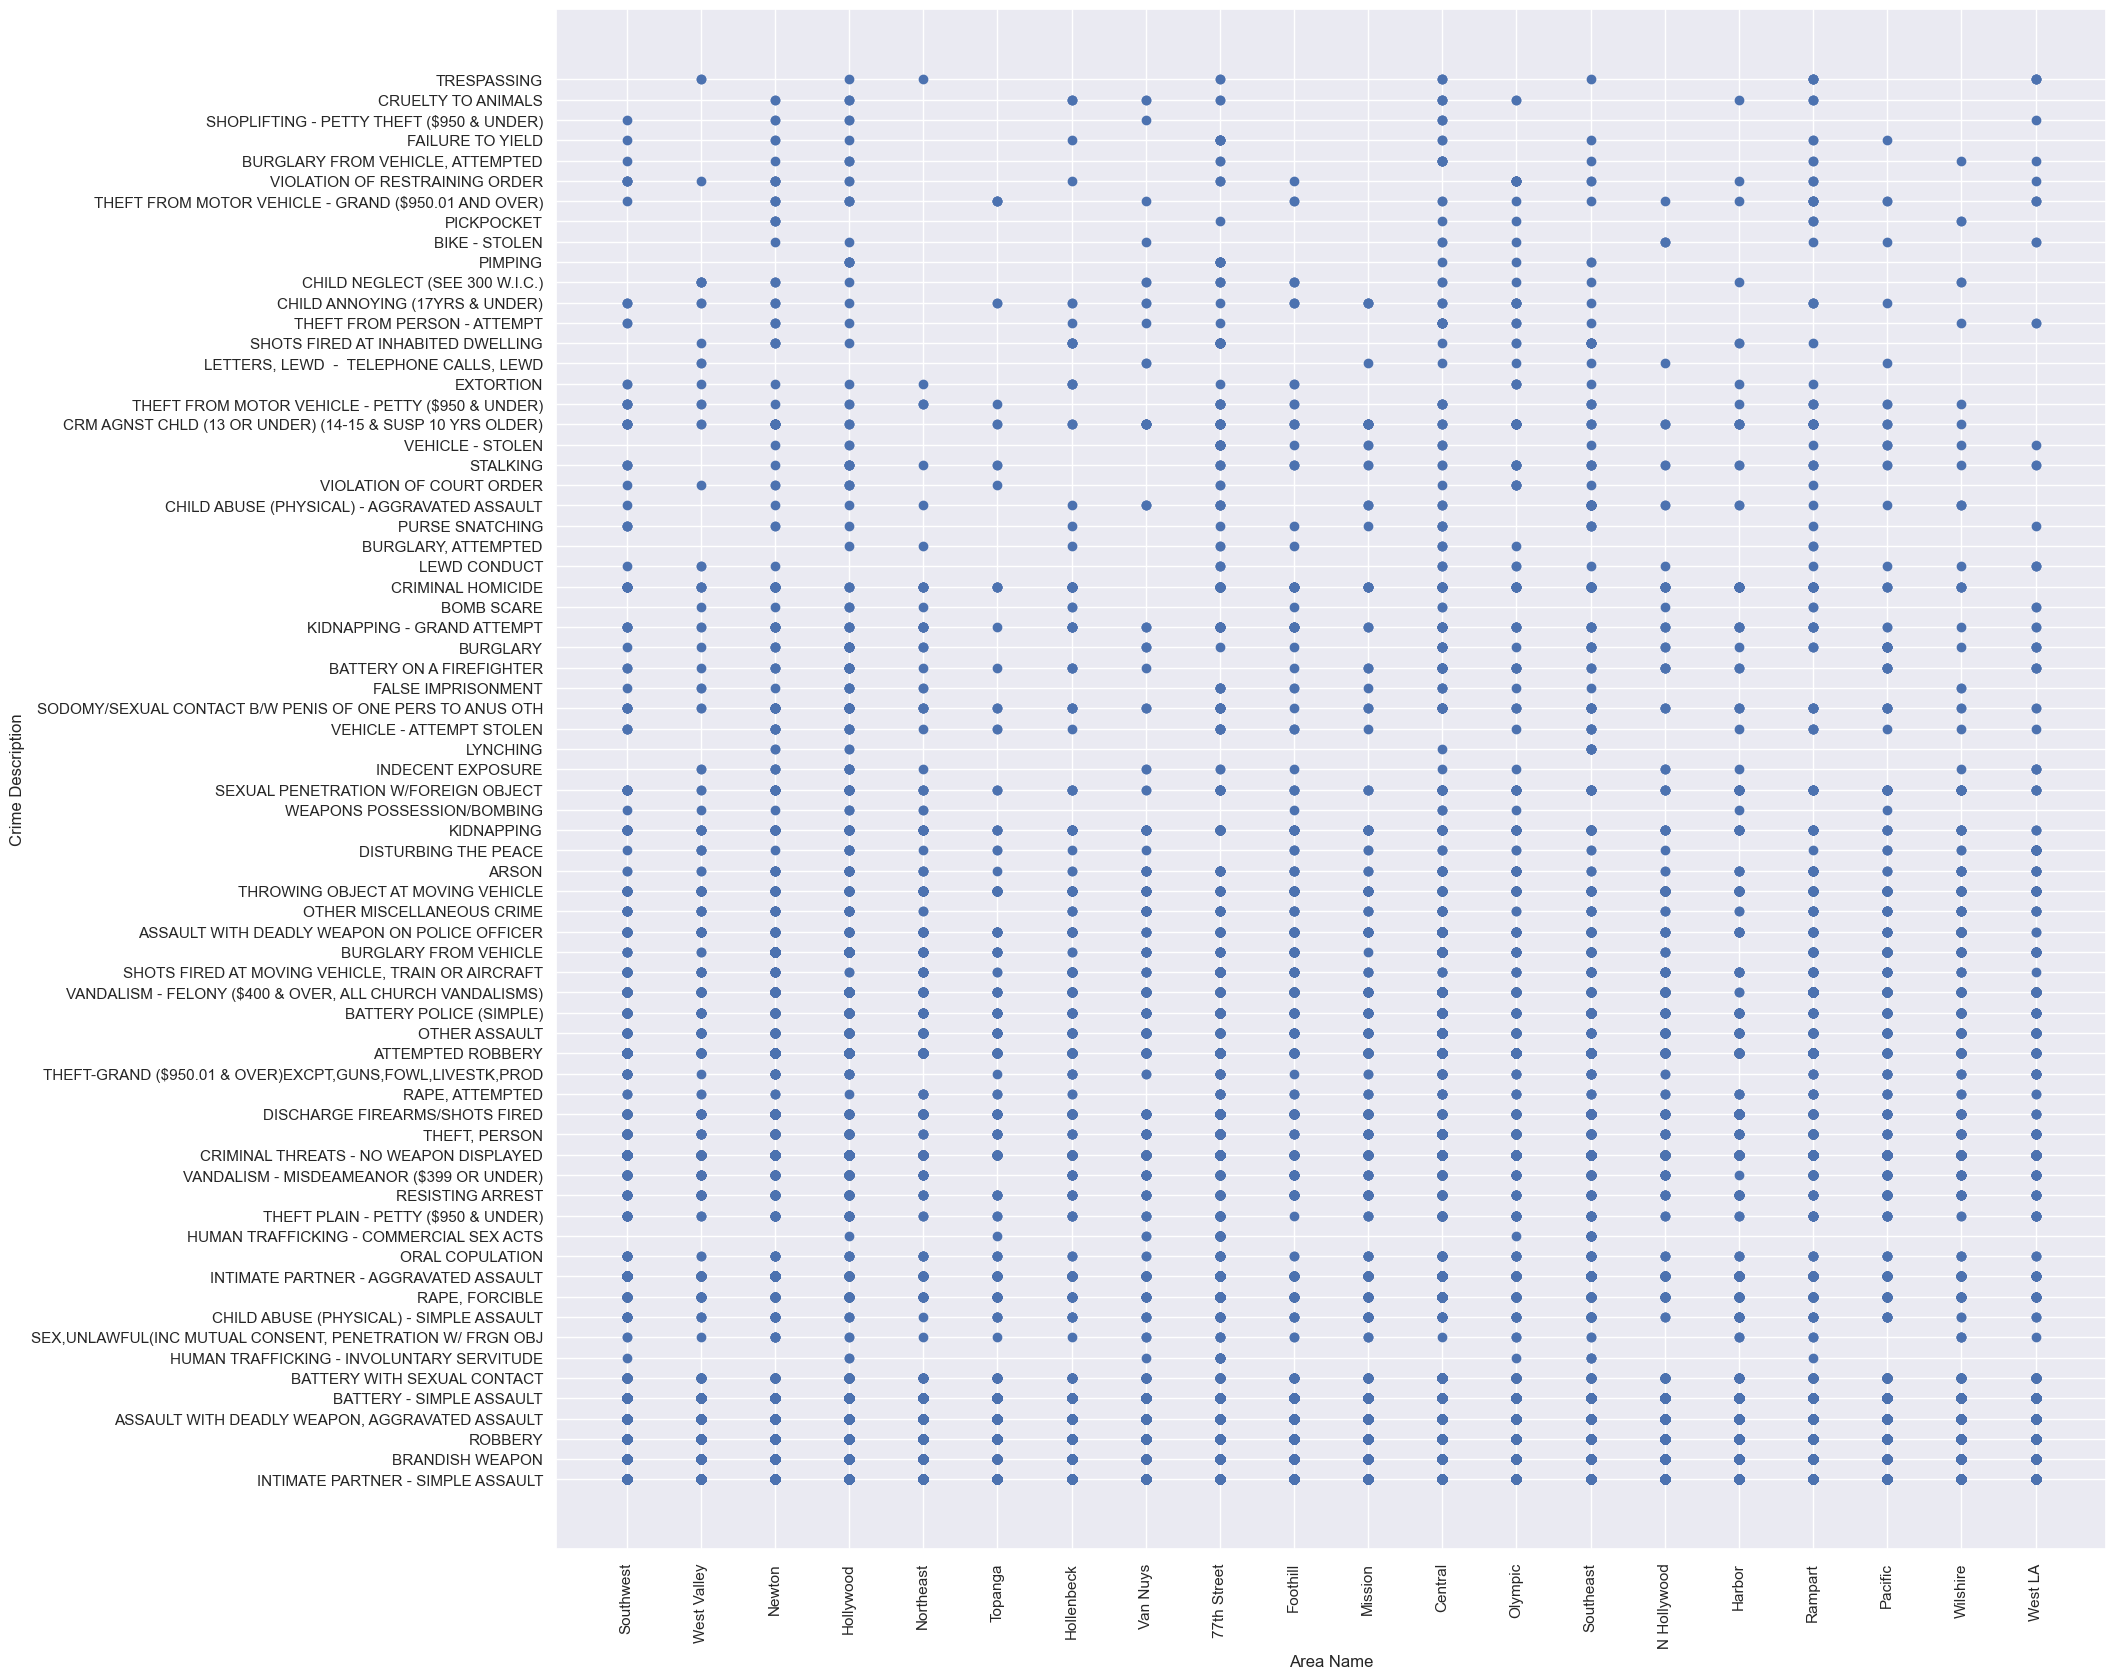

In [101]:
top_20_areas = df['AREA_NAME'].value_counts().nlargest(20).index
top_70_crimes = df['Crime_Code_Descript'].value_counts().nlargest(70).index

filtered_df = df[df['AREA_NAME'].isin(top_20_areas) & df['Crime_Code_Descript'].isin(top_70_crimes)]

fig, ax = plt.subplots(figsize=(20, 20))
ax.scatter(filtered_df['AREA_NAME'], filtered_df['Crime_Code_Descript'])
ax.set_xlabel('Area Name')
ax.set_ylabel('Crime Description')
plt.xticks(rotation=90)  # Rotate x-axis labels if needed
plt.show()


In [103]:
top_10_areas = df['AREA_NAME'].value_counts().nlargest(10).index
top_10_crimes = df['Crime_Code_Descript'].value_counts().nlargest(10).index
filtered_df = df[df['AREA_NAME'].isin(top_10_areas) & df['Crime_Code_Descript'].isin(top_10_crimes)]

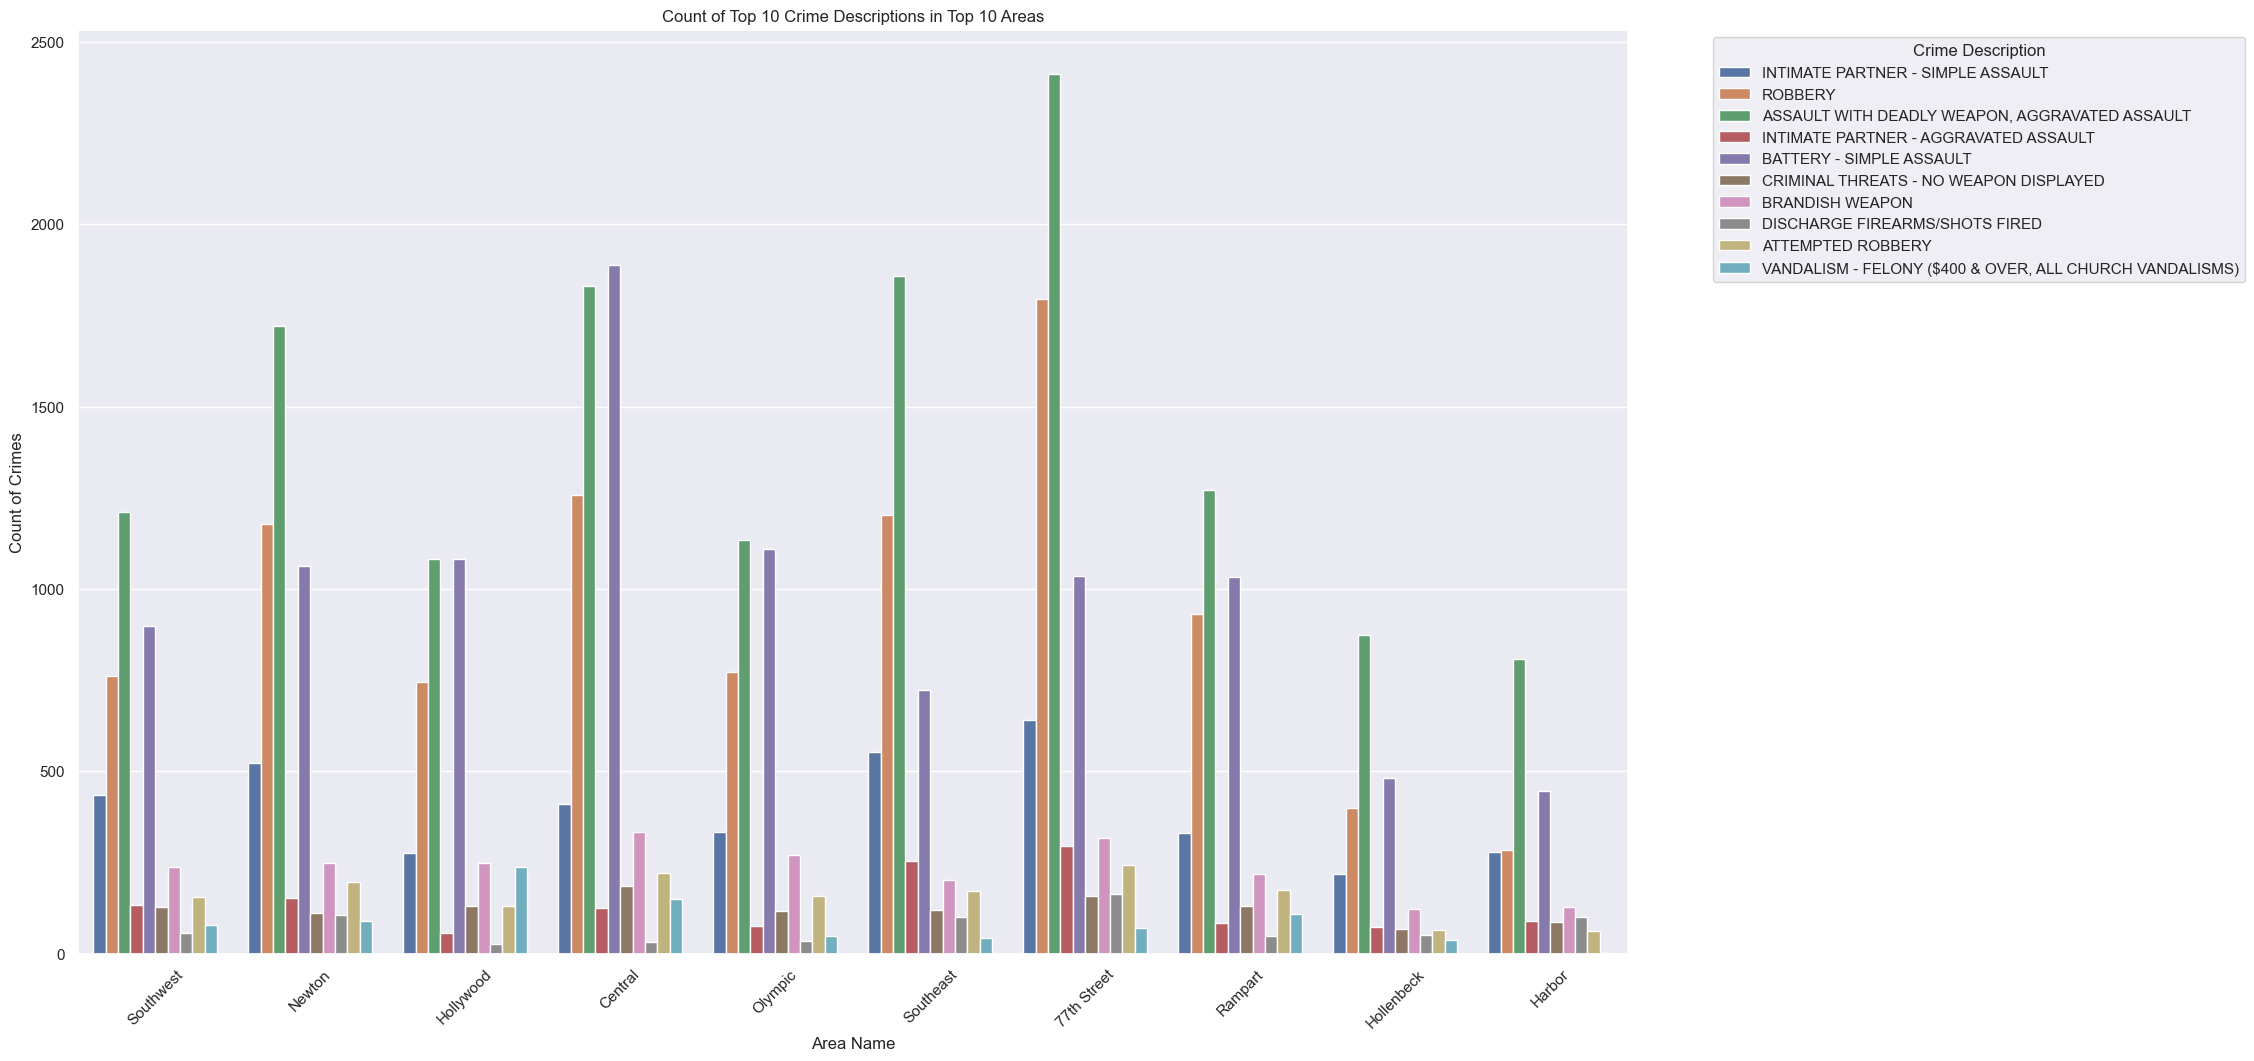

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 12))
ax = sns.countplot(x='AREA_NAME', hue='Crime_Code_Descript', data=filtered_df)
plt.xticks(rotation=45)
plt.xlabel('Area Name')
plt.ylabel('Count of Crimes')
plt.title('Count of Top 10 Crime Descriptions in Top 10 Areas')
plt.legend(title='Crime Description', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


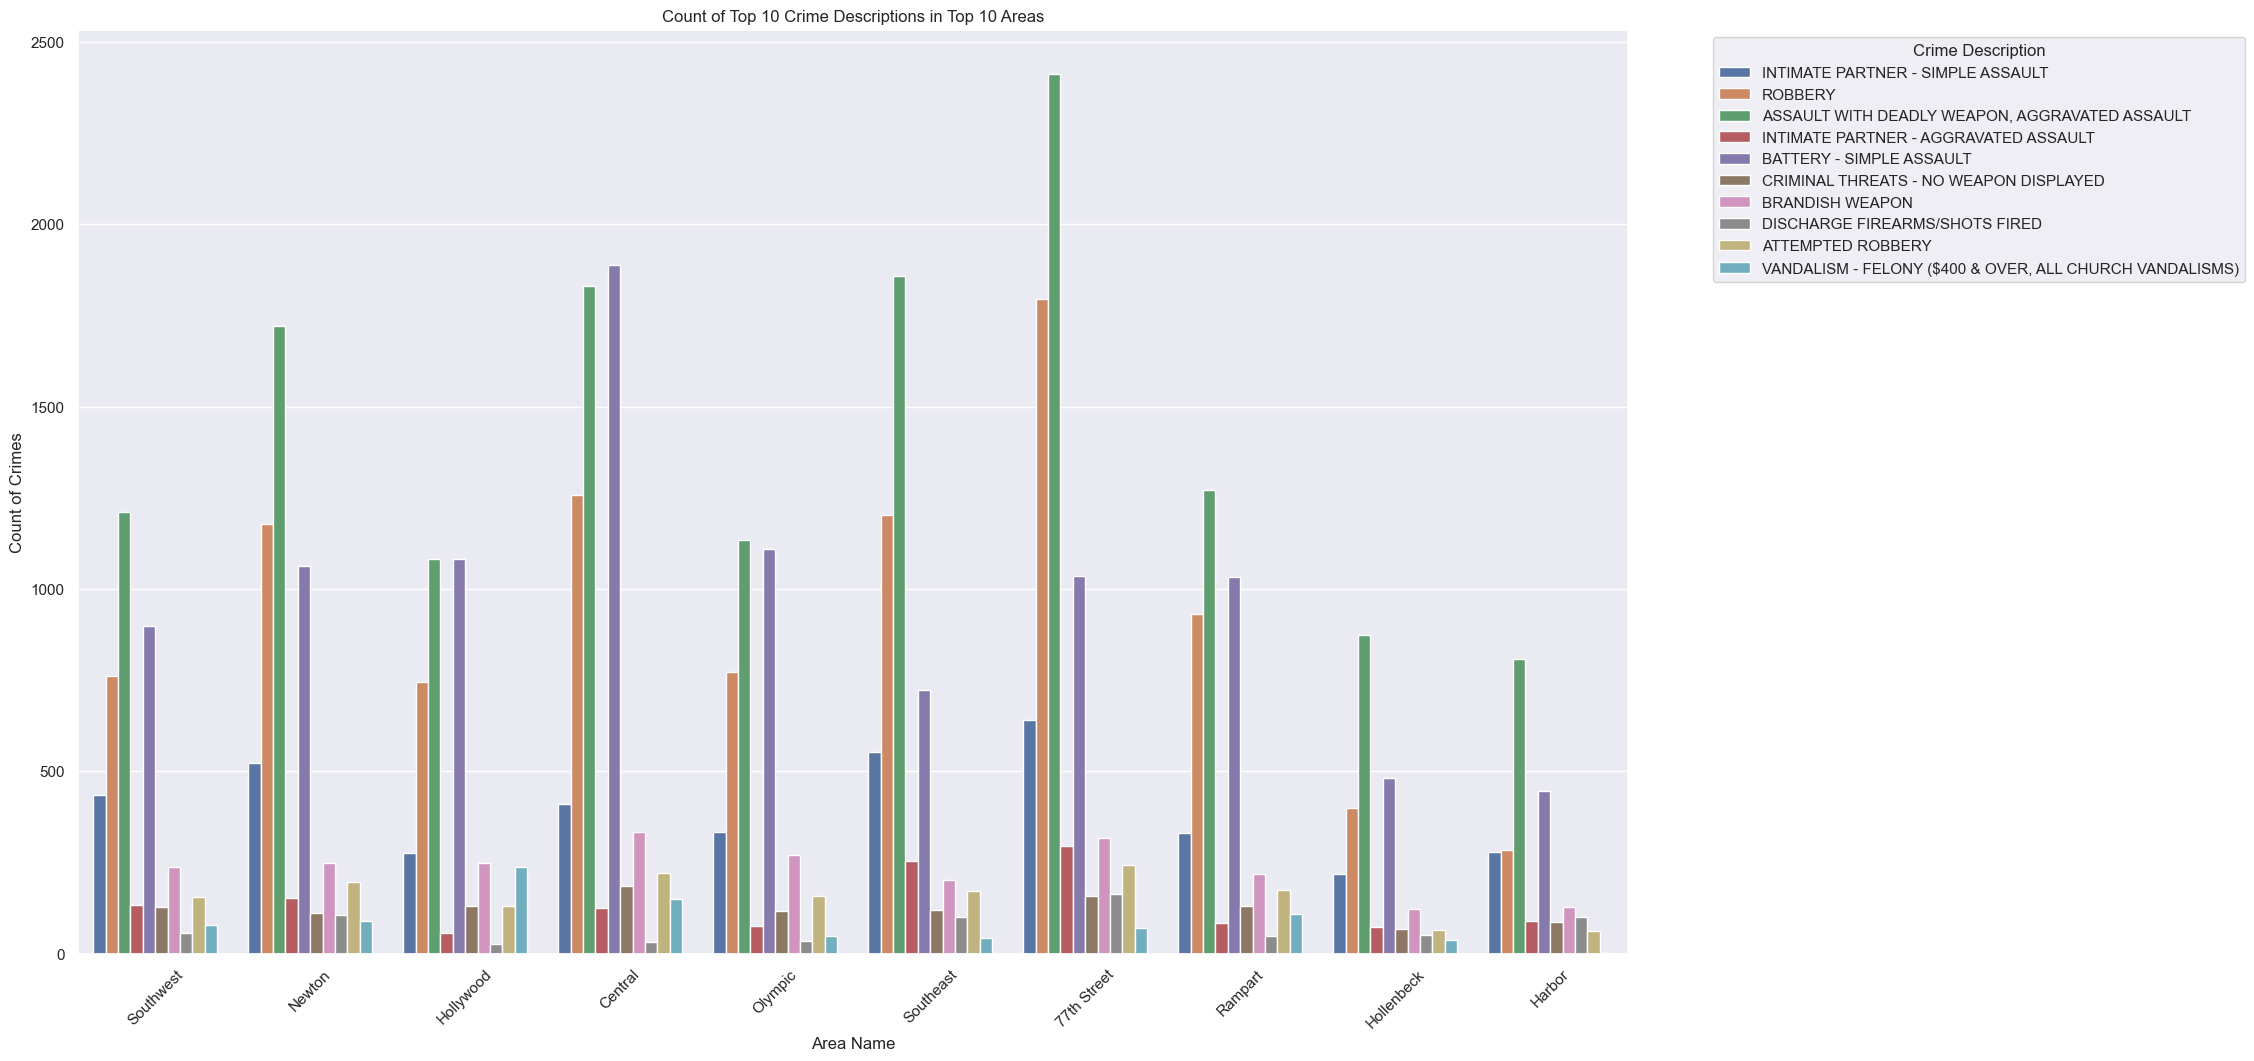

In [107]:
# Now working with the ML model Directly since the data has been already analyzed

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [112]:
# Converting 'DATE OCC' to datetime format
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])

# Convert 'TIME OCC' to a proper time format, handling errors
df['TIME OCC'] = pd.to_datetime(df['TIME OCC'], format='%H%M', errors='coerce').dt.time

# Fill missing or invalid times with a default value (e.g., midnight)
df['TIME OCC'].fillna(pd.to_datetime('0000', format='%H%M').time(), inplace=True)


In [113]:
# Combine date and time into a single datetime column
df['datetime'] = df.apply(lambda row: pd.Timestamp.combine(row['DATE OCC'], row['TIME OCC']), axis=1)

df.head(5)

,DATE OCC,TIME OCC,AREA,AREA_NAME,Crime Committed,Crime_Code_Descript,Modus Operandi,Vict Age,Vict Sex,Vict Descent,...,Premise Code Descript,Weapon Used Cd,Weapon Desc,Crime Status,Crime Status Descript,LOCATION,Cross Street,LAT,LON,datetime
91,2020-06-30,00:00:00,3,Southwest,626,INTIMATE PARTNER - SIMPLE ASSAULT,0913 2000 1814 0416 0446,25,F,B,...,SINGLE FAMILY DWELLING,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,VERMONT AV,43RD ST,34.0055,-118.2915,2020-06-30
150,2020-07-24,00:00:00,10,West Valley,761,BRANDISH WEAPON,1202 1822 0334,59,F,H,...,SIDEWALK,500.0,UNKNOWN WEAPON/OTHER WEAPON,IC,Invest Cont,SHERMAN WY,ENCINO,34.2012,-118.5133,2020-07-24
151,2020-03-01,00:00:00,10,West Valley,626,INTIMATE PARTNER - SIMPLE ASSAULT,2000 1813 0416,43,M,H,...,STREET,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AA,Adult Arrest,SHIRLEY,ROSCOE BL,34.2204,-118.5579,2020-03-01
210,2020-04-01,00:00:00,13,Newton,210,ROBBERY,1309 1313 0342 0444 0302 0449 1218 1822,50,X,H,...,BUS STOP,102.0,HAND GUN,IC,Invest Cont,12TH ST,SAN PEDRO ST,34.0337,-118.2533,2020-04-01
228,2020-07-02,00:00:00,6,Hollywood,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0400 0416 0444 1822 1501,52,M,W,...,SIDEWALK,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AO,Adult Other,YUCCA ST,HIGHLAND AV,34.1032,-118.3387,2020-07-02


In [115]:
# Feature engineering: Extract day of the week and hour from the datetime
df['day_of_week'] = df['datetime'].dt.dayofweek
df['hour'] = df['datetime'].dt.hour

In [117]:
# Step 3: Select features and target variable
features = ['LAT', 'LON', 'day_of_week', 'hour']
X = df[features]
y = df['Crime_Code_Descript']

In [118]:
# Step 4: Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [119]:
# Step 5: Implement the KNN Model
knn = KNeighborsClassifier(n_neighbors=10)  # You can tune the n_neighbors parameter
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=10)

In [120]:
# Step 6: Make Predictions
y_pred = knn.predict(X_test)

In [121]:
# Step 7: Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

C:\Users\oryou\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Accuracy: 0.25
Precision: 0.19
Recall: 0.25
F1 Score: 0.20


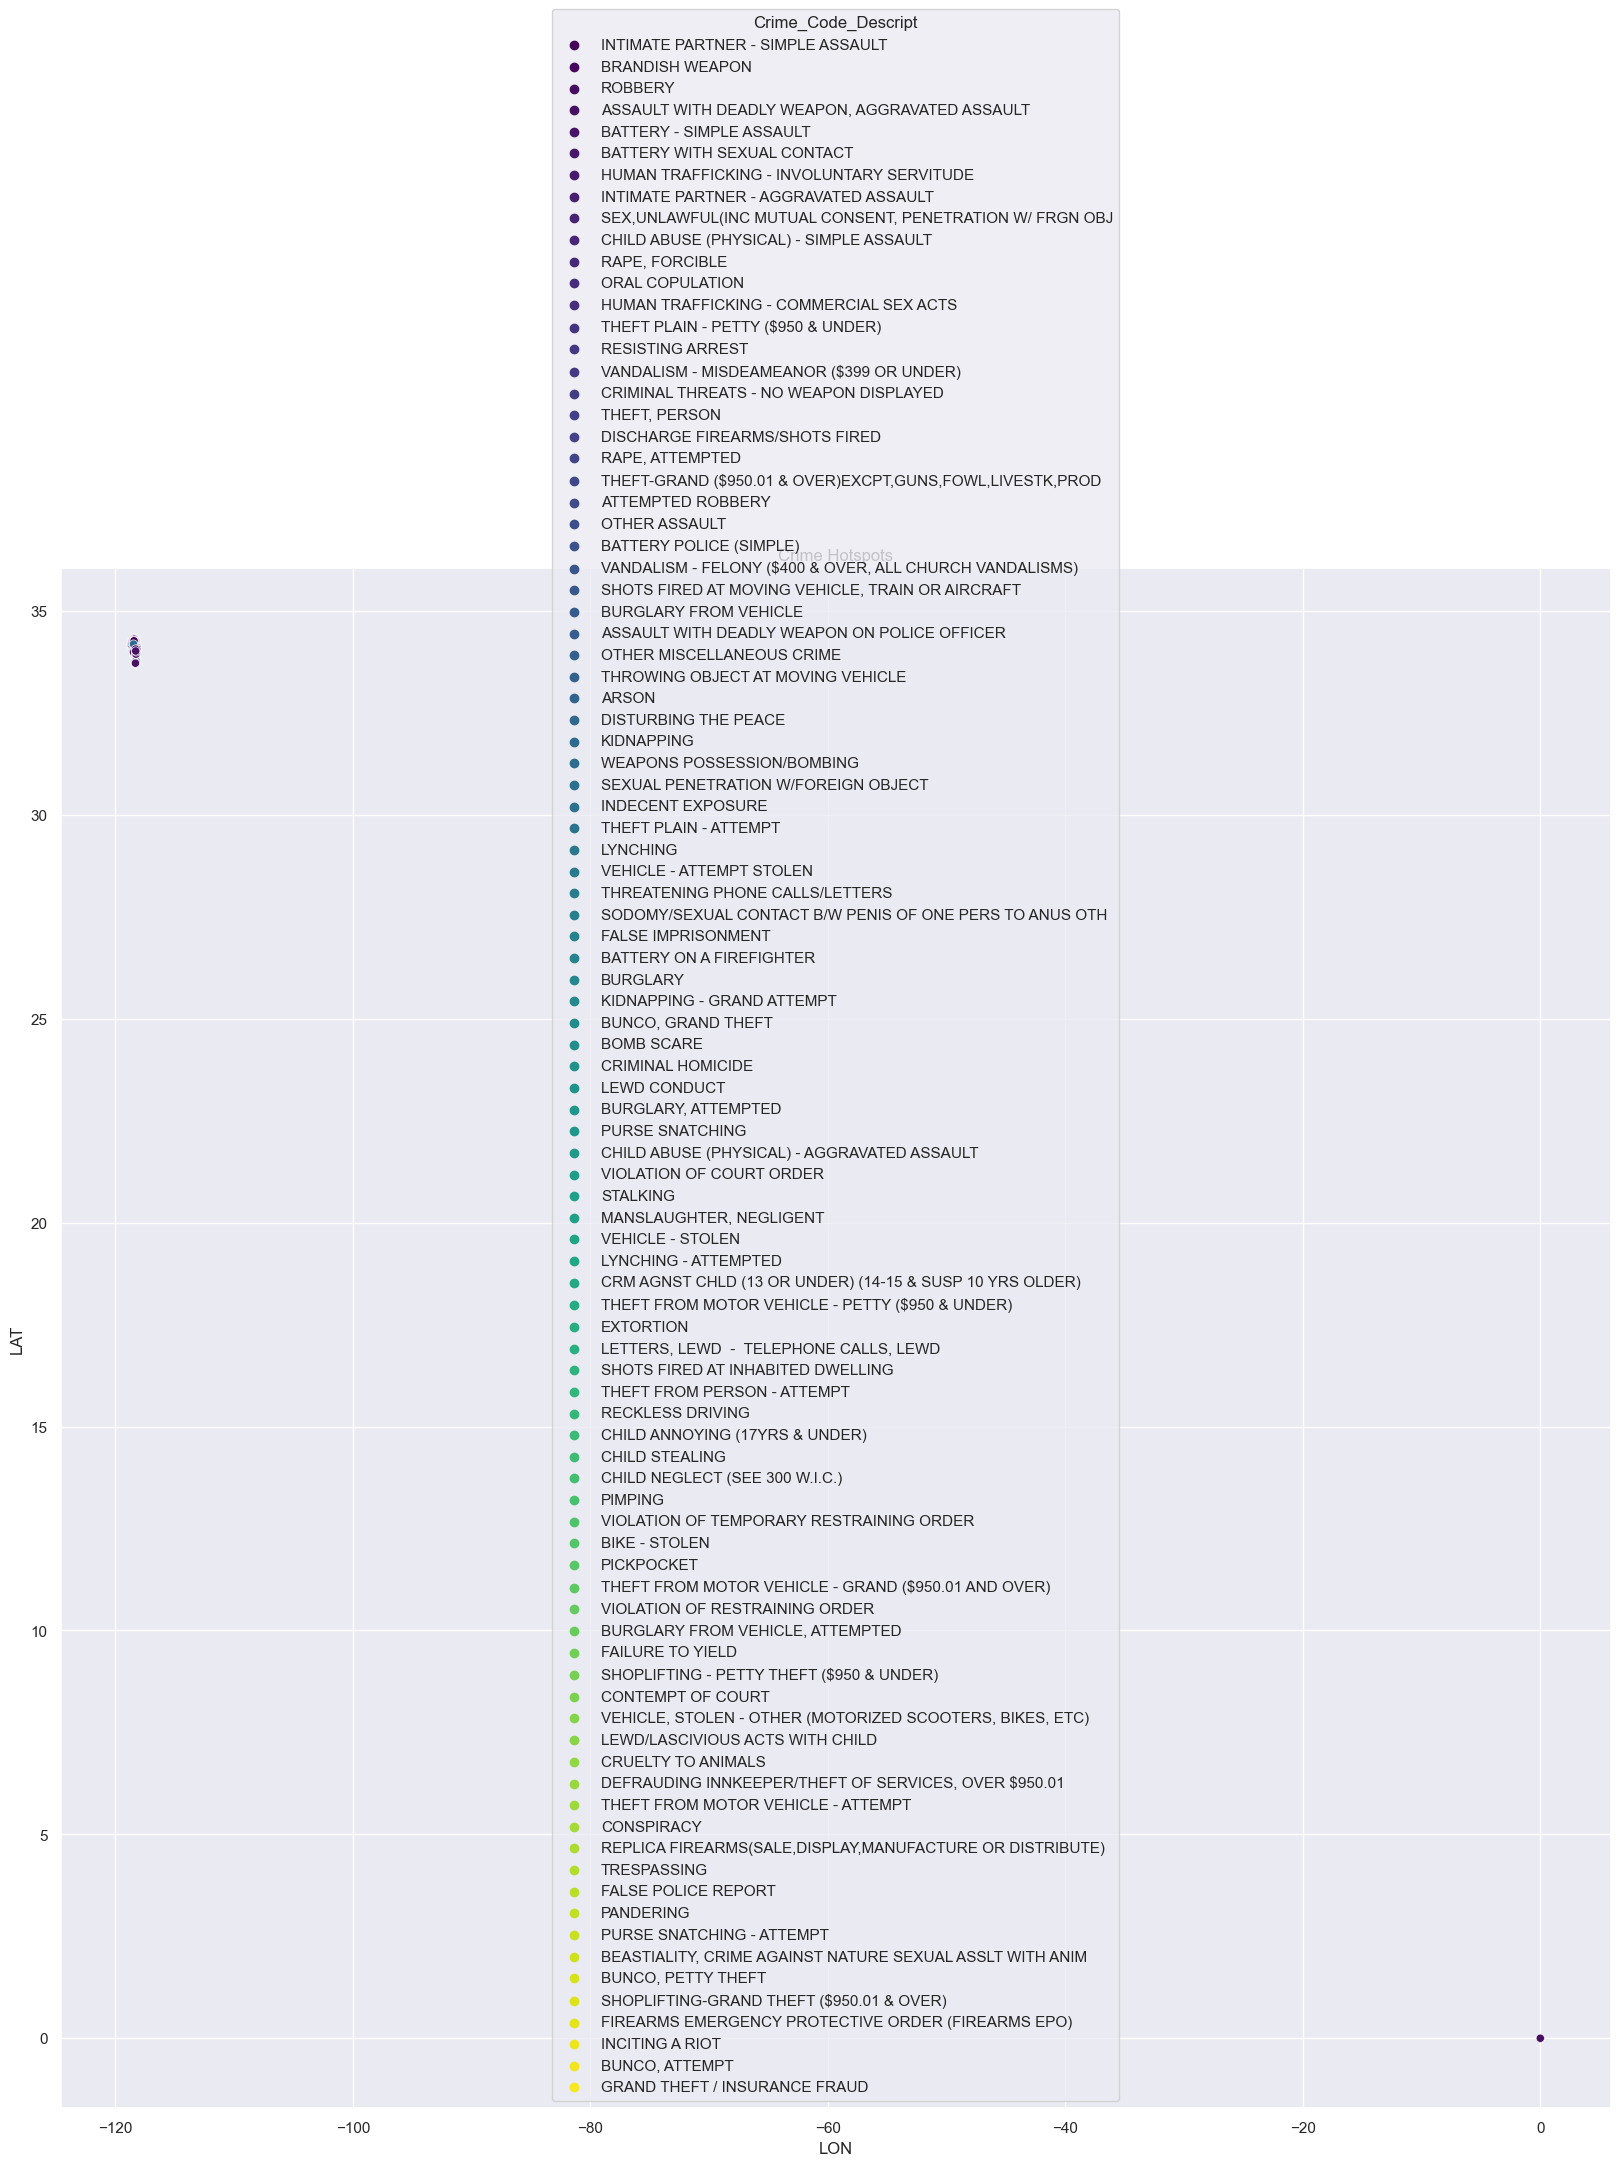

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 20))
sns.scatterplot(x='LON', y='LAT', hue='Crime_Code_Descript', data=df, palette='viridis')
plt.title('Crime Hotspots')
plt.show()


In [129]:
print(df[['LON', 'LAT']].describe())
print(df[['LON', 'LAT']].head())


                LON           LAT
count  75012.000000  75012.000000
mean    -117.994009     33.956431
std        6.237650      1.797679
min     -118.666600      0.000000
25%     -118.357700     33.993300
50%     -118.291600     34.045000
75%     -118.265200     34.094400
max        0.000000     34.334300
          LON      LAT
91  -118.2915  34.0055
150 -118.5133  34.2012
151 -118.5579  34.2204
210 -118.2533  34.0337
228 -118.3387  34.1032


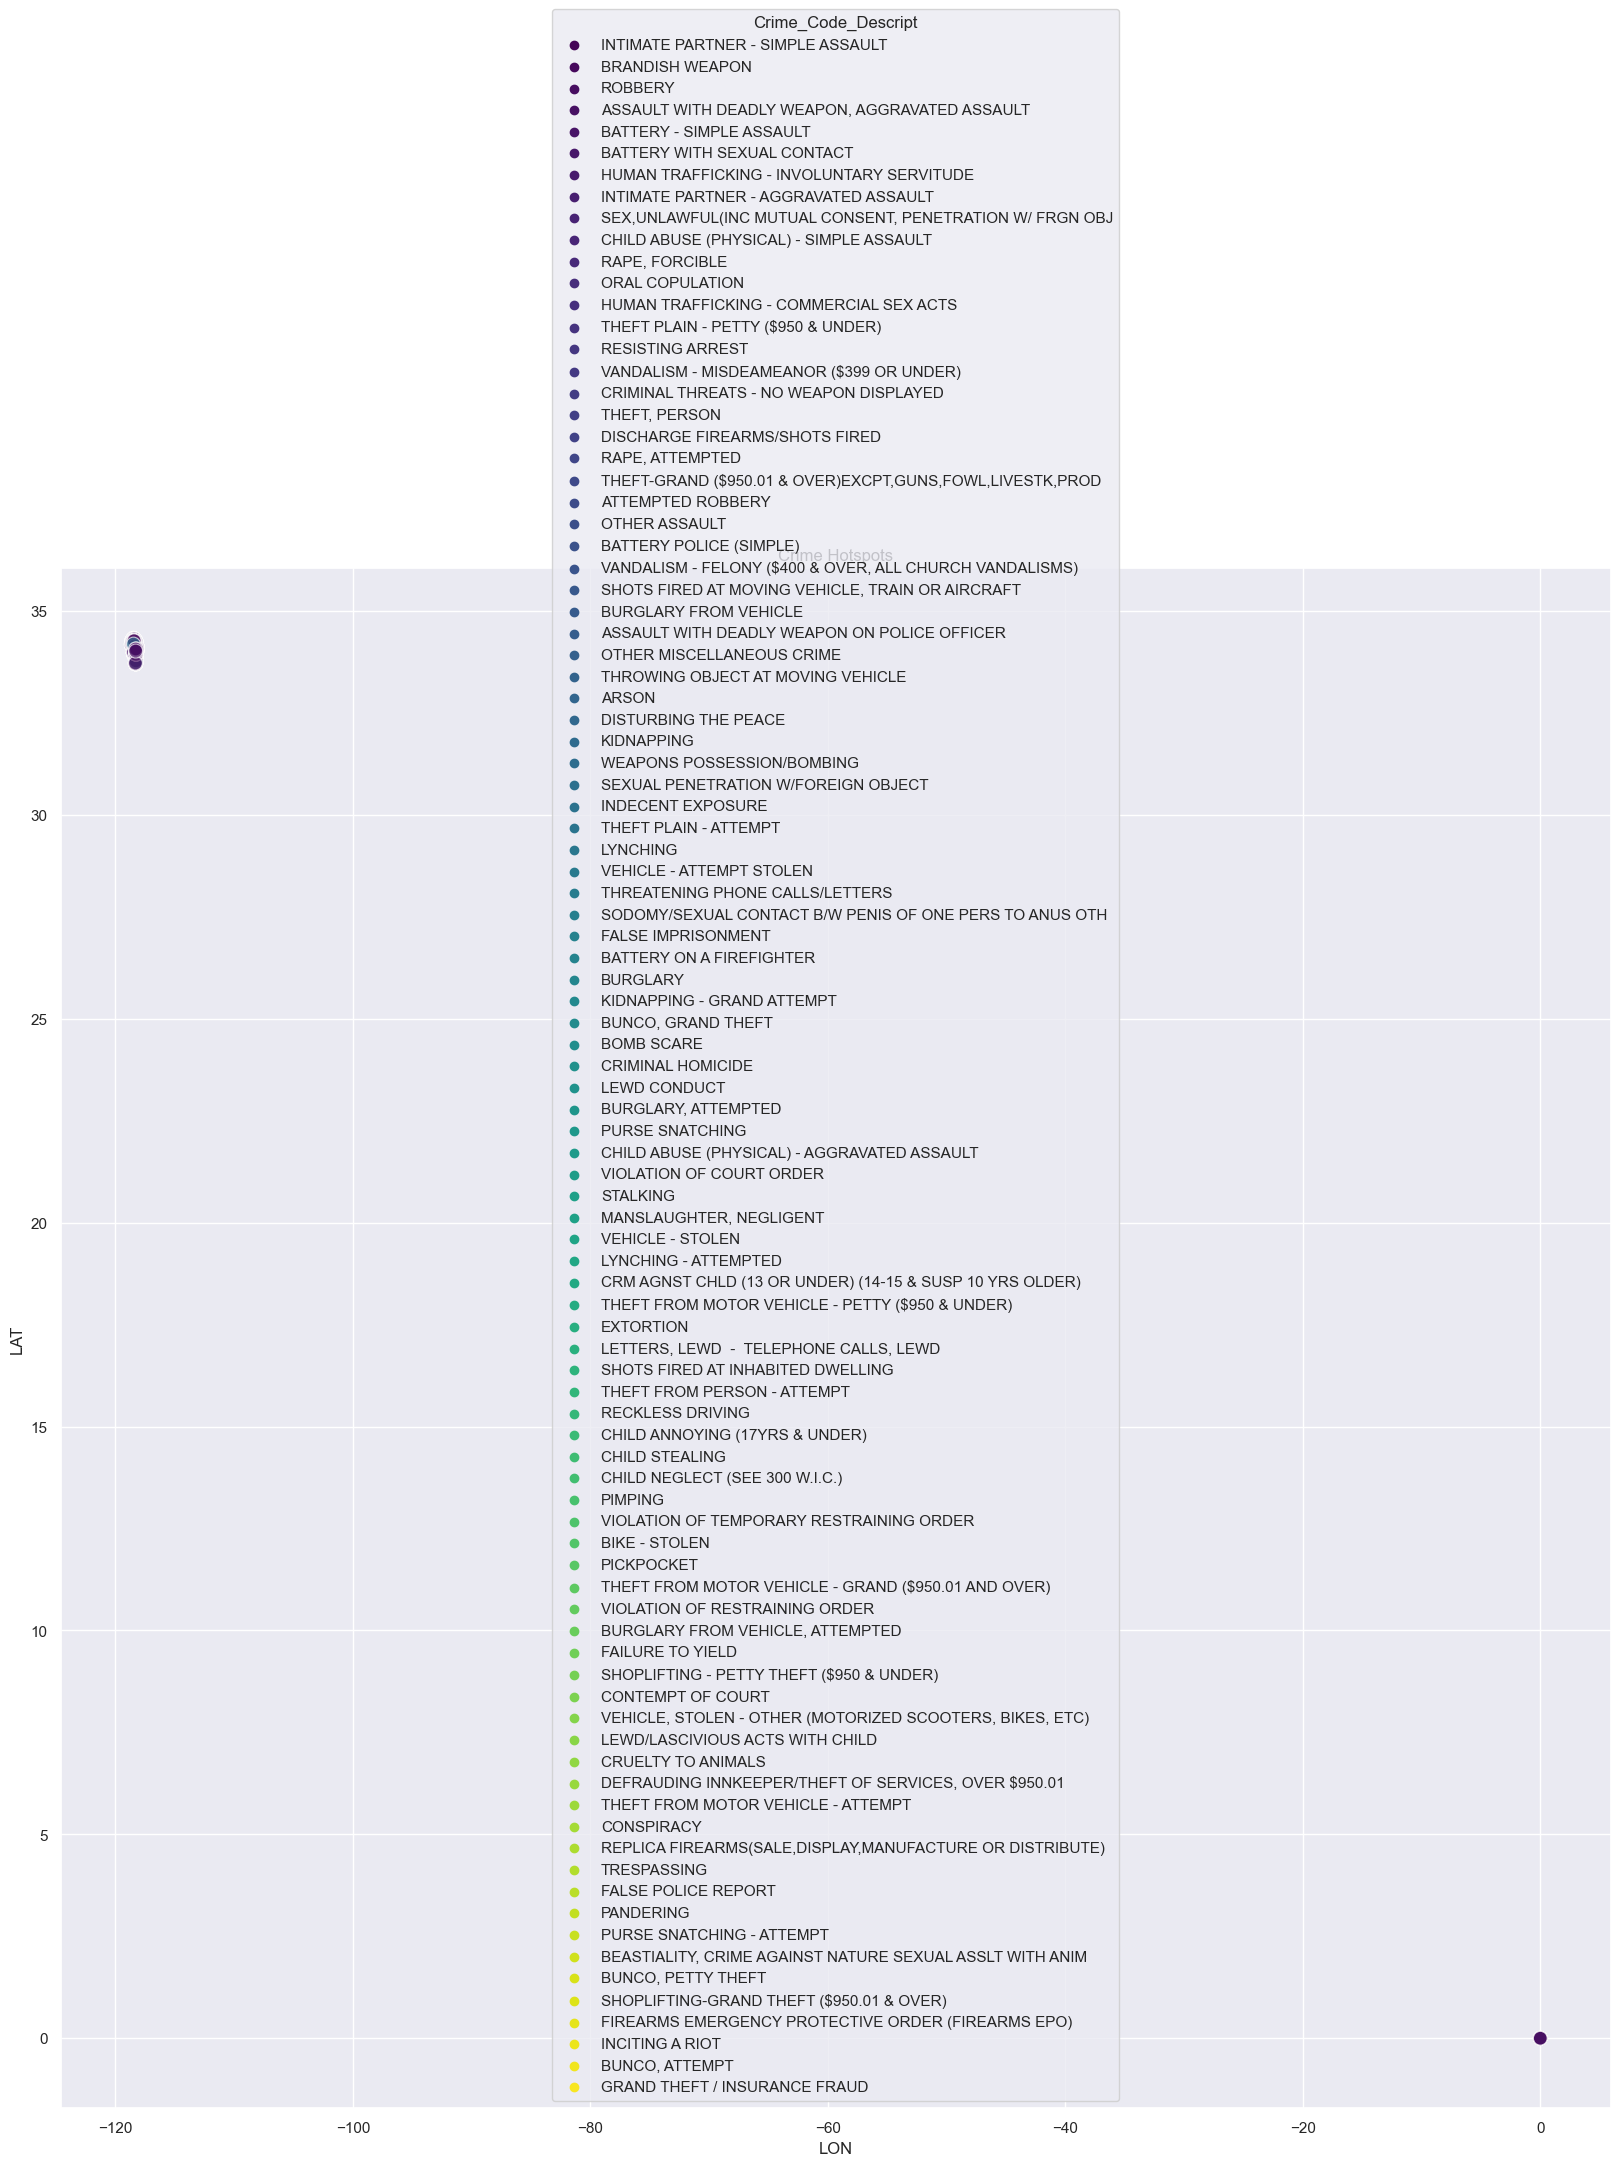

In [130]:
plt.figure(figsize=(20, 20))
sns.scatterplot(x='LON', y='LAT', hue='Crime_Code_Descript', data=df, palette='viridis', alpha=0.7, edgecolor='w', s=100)
plt.title('Crime Hotspots')
plt.show()


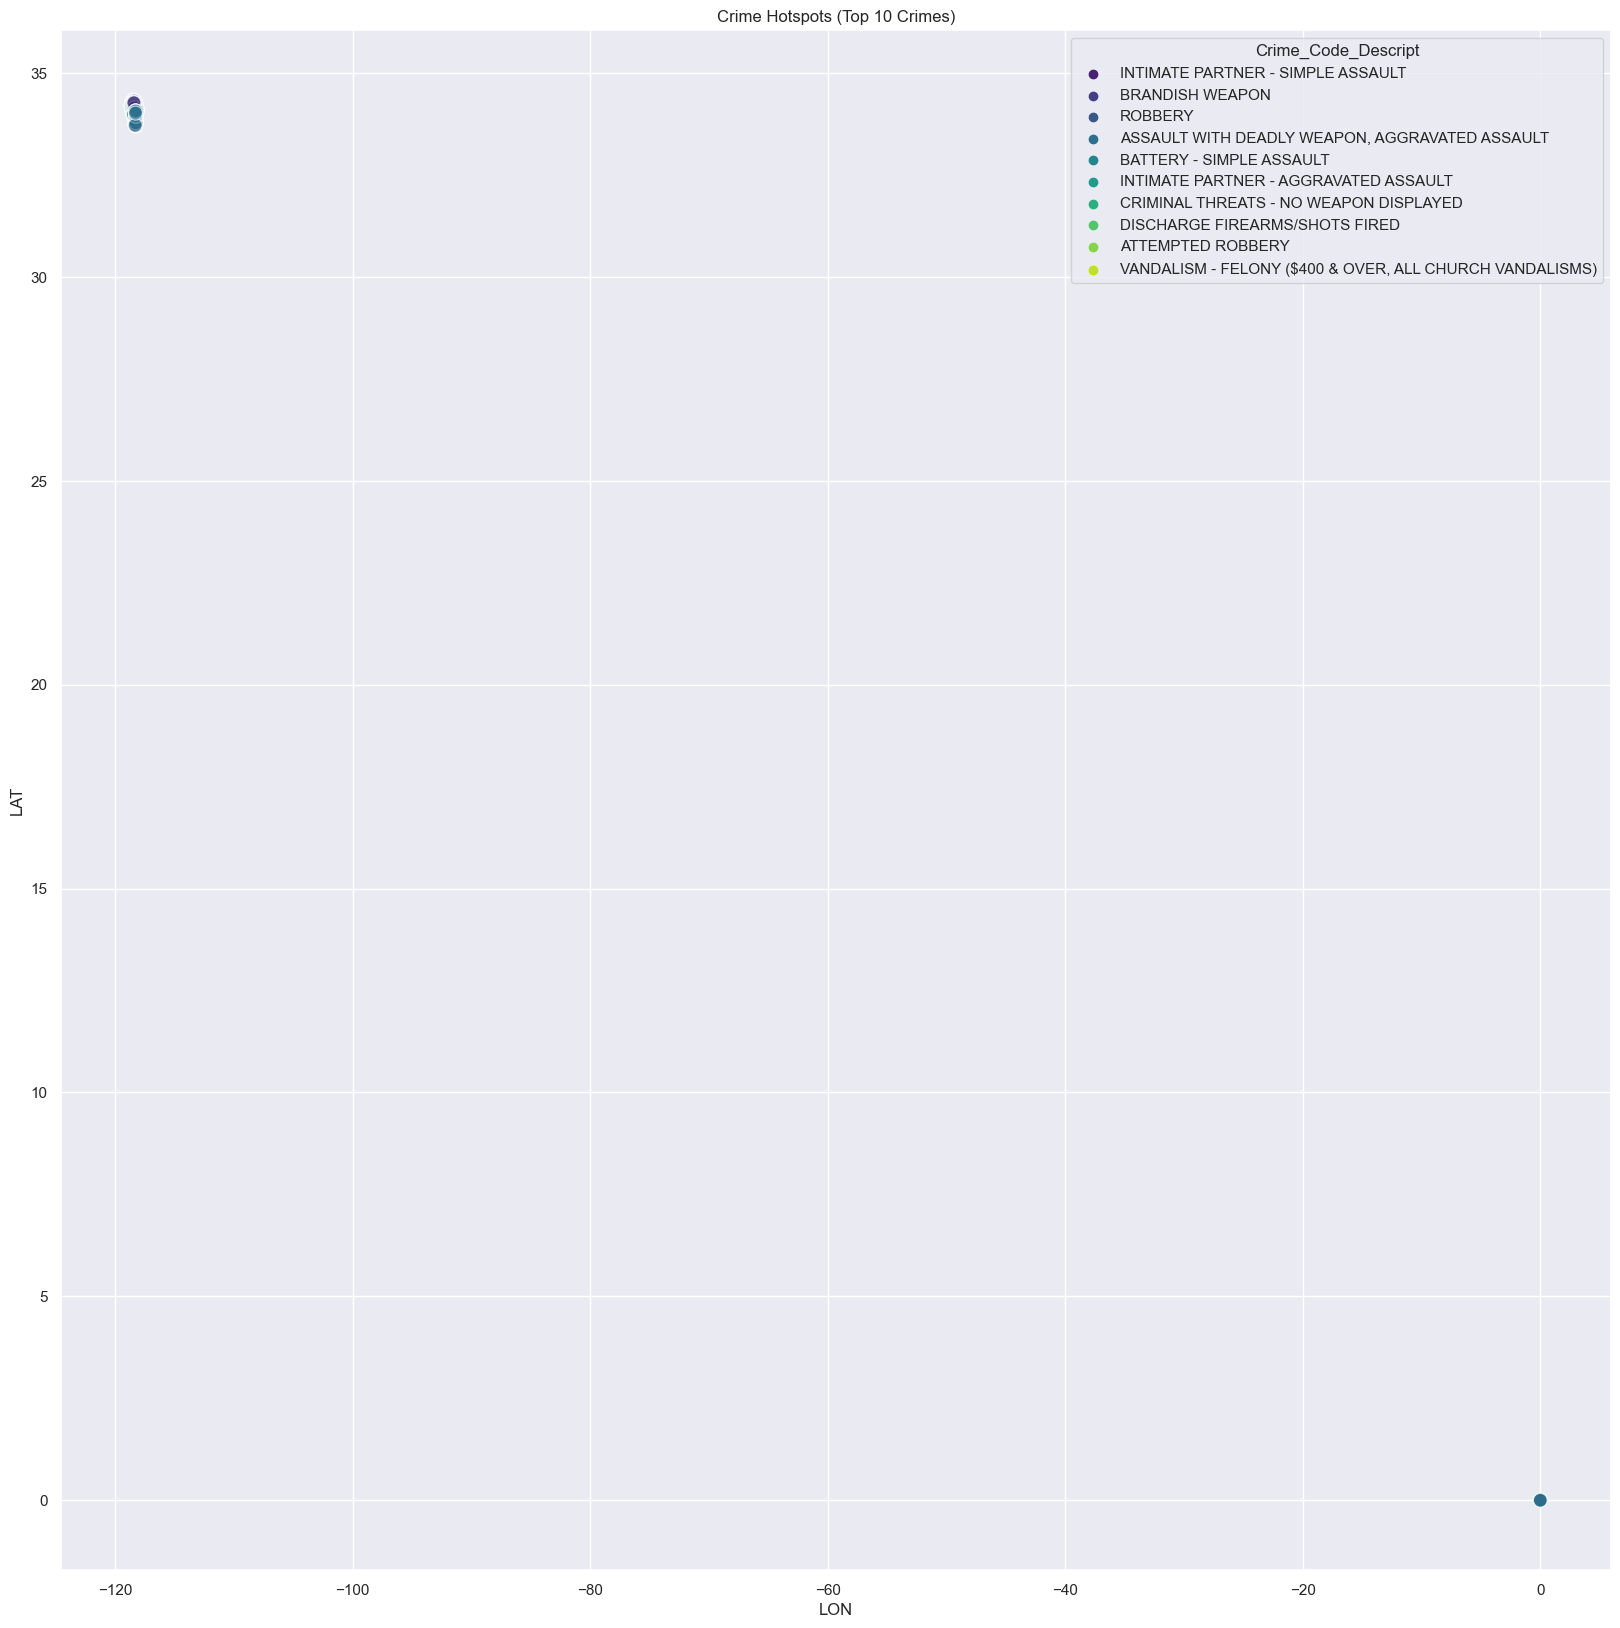

In [132]:
top_crimes = df['Crime_Code_Descript'].value_counts().nlargest(10).index
filtered_df = df[df['Crime_Code_Descript'].isin(top_crimes)]

plt.figure(figsize=(20, 20))
sns.scatterplot(x='LON', y='LAT', hue='Crime_Code_Descript', data=filtered_df, palette='viridis', alpha=0.7, edgecolor='w', s=100)
plt.title('Crime Hotspots (Top 10 Crimes)')
plt.show()


In [133]:
# Working on Improving the model's accuracy (currently it is a 25%)

 print(y_train.value_counts())


ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT          15740
BATTERY - SIMPLE ASSAULT                                11821
ROBBERY                                                  9669
INTIMATE PARTNER - SIMPLE ASSAULT                        4859
BRANDISH WEAPON                                          2755
                                                        ...  
DEFRAUDING INNKEEPER/THEFT OF SERVICES, OVER $950.01        1
GRAND THEFT / INSURANCE FRAUD                               1
MANSLAUGHTER, NEGLIGENT                                     1
SHOPLIFTING-GRAND THEFT ($950.01 & OVER)                    1
FIREARMS EMERGENCY PROTECTIVE ORDER (FIREARMS EPO)          1
Name: Crime_Code_Descript, Length: 95, dtype: int64


In [136]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)


In [137]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)


In [138]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {'n_neighbors': range(1, 31)}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid_search.fit(X_train_scaled, y_train_res)
print(grid_search.best_params_)


{'n_neighbors': 30}


In [139]:
knn_best = grid_search.best_estimator_
y_pred = knn_best.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')


Accuracy: 0.05
Precision: 0.23
Recall: 0.05
F1 Score: 0.04


C:\Users\oryou\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [145]:
print(df.isnull().sum())  # Check for missing values
print(df.describe())      # Check for outliers and data distribution


DATE OCC                 0
TIME OCC                 0
AREA                     0
AREA_NAME                0
Crime Committed          0
Crime_Code_Descript      0
Modus Operandi           0
Vict Age                 0
Vict Sex                 0
Vict Descent             0
Premis Cd                0
Premise Code Descript    0
Weapon Used Cd           0
Weapon Desc              0
Crime Status             0
Crime Status Descript    0
LOCATION                 0
Cross Street             0
LAT                      0
LON                      0
datetime                 0
day_of_week              0
hour                     0
dtype: int64
               AREA  Crime Committed      Vict Age     Premis Cd  \
count  75012.000000     75012.000000  75012.000000  75012.000000   
mean      10.084413       439.117781     34.808391    155.916827   
std        6.312757       238.464588     17.040884    168.623980   
min        1.000000       110.000000     -2.000000    101.000000   
25%        4.000000       

In [146]:
# Trying different models

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

# Try Random Forest
rf = RandomForestClassifier(random_state=42)
rf_scores = cross_val_score(rf, X_train_scaled, y_train_res, cv=5, scoring='accuracy')
print(f'Random Forest CV Accuracy: {rf_scores.mean():.2f}')

# Try Gradient Boosting
#gb = GradientBoostingClassifier(random_state=42)
#gb_scores = cross_val_score(gb, X_train_scaled, y_train_res, cv=5, scoring='accuracy')
#print(f'Gradient Boosting CV Accuracy: {gb_scores.mean():.2f}')


Random Forest CV Accuracy: 0.94


In [147]:
# Fitting the model on the entire training data
rf.fit(X_train_scaled, y_train_res)

# Predictin on the test data
y_pred_test = rf.predict(X_test_scaled)

# Evaluating the performance on test data
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
recall_test = recall_score(y_test, y_pred_test, average='weighted')
f1_test = f1_score(y_test, y_pred_test, average='weighted')

print(f'Test Accuracy: {accuracy_test:.2f}')
print(f'Test Precision: {precision_test:.2f}')
print(f'Test Recall: {recall_test:.2f}')
print(f'Test F1 Score: {f1_test:.2f}')


Test Accuracy: 0.17
Test Precision: 0.21
Test Recall: 0.17
Test F1 Score: 0.18


C:\Users\oryou\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


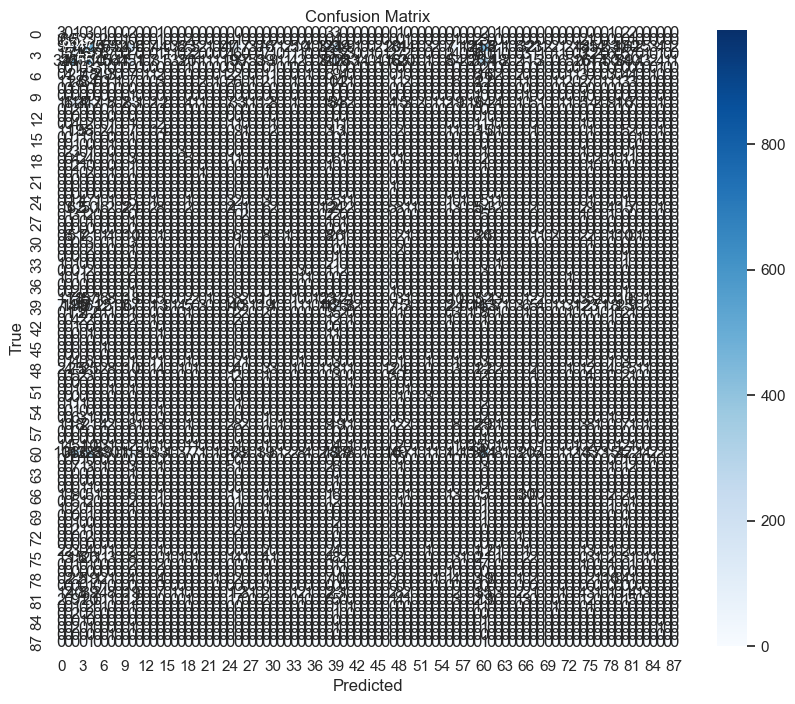

C:\Users\oryou\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\oryou\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\oryou\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\oryou\anaconda3\Lib\site-packages\sklearn\metrics\_cla

                                                          precision    recall  f1-score   support

                                                   ARSON       0.04      0.12      0.06        26
            ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER       0.32      0.67      0.44        98
          ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT       0.37      0.24      0.29      4017
                                       ATTEMPTED ROBBERY       0.03      0.04      0.03       404
                                BATTERY - SIMPLE ASSAULT       0.26      0.19      0.22      2914
                                BATTERY ON A FIREFIGHTER       0.06      0.20      0.10        15
                                 BATTERY POLICE (SIMPLE)       0.18      0.26      0.21       186
                             BATTERY WITH SEXUAL CONTACT       0.04      0.06      0.05       195
                                           BIKE - STOLEN       0.00      0.00      0.00         0
                   

C:\Users\oryou\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\oryou\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [151]:
from sklearn.metrics import confusion_matrix, classification_report

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_test))


In [152]:
import pandas as pd

# Convert to DataFrame if needed
y_series = pd.Series(y)

# Check the distribution of the target variable
print(y_series.value_counts())


ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT              19757
BATTERY - SIMPLE ASSAULT                                    14735
ROBBERY                                                     11989
INTIMATE PARTNER - SIMPLE ASSAULT                            6060
BRANDISH WEAPON                                              3478
                                                            ...  
BEASTIALITY, CRIME AGAINST NATURE SEXUAL ASSLT WITH ANIM        1
FIREARMS EMERGENCY PROTECTIVE ORDER (FIREARMS EPO)              1
INCITING A RIOT                                                 1
BUNCO, ATTEMPT                                                  1
GRAND THEFT / INSURANCE FRAUD                                   1
Name: Crime_Code_Descript, Length: 95, dtype: int64


In [153]:
# Set the minimum number of samples required for each class
min_samples = 2

# Identify classes with fewer than min_samples
class_counts = y_series.value_counts()
rare_classes = class_counts[class_counts < min_samples].index

# Remove rare classes
mask = ~y_series.isin(rare_classes)
X_filtered = X[mask]
y_filtered = y_series[mask]

print(y_filtered.value_counts())  # Check the new distribution


ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT              19757
BATTERY - SIMPLE ASSAULT                                    14735
ROBBERY                                                     11989
INTIMATE PARTNER - SIMPLE ASSAULT                            6060
BRANDISH WEAPON                                              3478
                                                            ...  
VIOLATION OF TEMPORARY RESTRAINING ORDER                        3
REPLICA FIREARMS(SALE,DISPLAY,MANUFACTURE OR DISTRIBUTE)        3
LYNCHING - ATTEMPTED                                            3
CHILD STEALING                                                  2
SHOPLIFTING-GRAND THEFT ($950.01 & OVER)                        2
Name: Crime_Code_Descript, Length: 86, dtype: int64


In [154]:
# Now performming Stratified Split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Perform a stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and fit the Random Forest model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

# Predict on the test data
y_pred_test_rf = rf.predict(X_test_scaled)

# Evaluate the performance on test data
accuracy_test_rf = accuracy_score(y_test, y_pred_test_rf)
precision_test_rf = precision_score(y_test, y_pred_test_rf, average='weighted', zero_division=1)
recall_test_rf = recall_score(y_test, y_pred_test_rf, average='weighted', zero_division=1)
f1_test_rf = f1_score(y_test, y_pred_test_rf, average='weighted', zero_division=1)

print(f'Test Accuracy (RF): {accuracy_test_rf:.2f}')
print(f'Test Precision (RF): {precision_test_rf:.2f}')
print(f'Test Recall (RF): {recall_test_rf:.2f}')
print(f'Test F1 Score (RF): {f1_test_rf:.2f}')

# Print classification report
print('Random Forest Classification Report:')
print(classification_report(y_test, y_pred_test_rf, zero_division=1))


Test Accuracy (RF): 0.24
Test Precision (RF): 0.22
Test Recall (RF): 0.24
Test F1 Score (RF): 0.23
Random Forest Classification Report:
                                                          precision    recall  f1-score   support

                                                   ARSON       0.23      0.11      0.15        28
            ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER       0.46      0.45      0.46       109
          ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT       0.34      0.43      0.38      3951
                                       ATTEMPTED ROBBERY       0.04      0.02      0.03       424
                                BATTERY - SIMPLE ASSAULT       0.27      0.32      0.30      2947
                                BATTERY ON A FIREFIGHTER       0.22      0.12      0.16        16
                                 BATTERY POLICE (SIMPLE)       0.26      0.24      0.25       167
                             BATTERY WITH SEXUAL CONTACT       0.07      0.04  

In [156]:
# Handling Data Imbalance

import pandas as pd

# Convert to DataFrame if needed
y_series = pd.Series(y_train)

# Check the distribution of the target variable
class_counts = y_series.value_counts()
print(class_counts)

# Set the minimum number of samples required for each class
min_samples = 6

# Identify classes with fewer than min_samples
rare_classes = class_counts[class_counts < min_samples].index

# Remove rare classes
mask = ~y_series.isin(rare_classes)
X_train_filtered = X_train[mask]
y_train_filtered = y_series[mask]

print(y_train_filtered.value_counts())  # Check the new distribution



ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT    15806
BATTERY - SIMPLE ASSAULT                          11788
ROBBERY                                            9591
INTIMATE PARTNER - SIMPLE ASSAULT                  4848
BRANDISH WEAPON                                    2782
                                                  ...  
CONSPIRACY                                            3
LEWD/LASCIVIOUS ACTS WITH CHILD                       3
PURSE SNATCHING - ATTEMPT                             3
CHILD STEALING                                        2
SHOPLIFTING-GRAND THEFT ($950.01 & OVER)              2
Name: Crime_Code_Descript, Length: 86, dtype: int64
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT    15806
BATTERY - SIMPLE ASSAULT                          11788
ROBBERY                                            9591
INTIMATE PARTNER - SIMPLE ASSAULT                  4848
BRANDISH WEAPON                                    2782
                                                  ..

In [158]:
from imblearn.over_sampling import RandomOverSampler

# Apply RandomOverSampler to the training data
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

# Check the new class distribution
print('Resampled dataset shape %s' % Counter(y_train_res))


Resampled dataset shape Counter({'BATTERY - SIMPLE ASSAULT': 15806, 'ROBBERY': 15806, 'FAILURE TO YIELD': 15806, 'ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT': 15806, 'BRANDISH WEAPON': 15806, 'ATTEMPTED ROBBERY': 15806, 'BATTERY POLICE (SIMPLE)': 15806, 'VEHICLE - ATTEMPT STOLEN': 15806, 'VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)': 15806, 'ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER': 15806, 'INTIMATE PARTNER - AGGRAVATED ASSAULT': 15806, 'CHILD NEGLECT (SEE 300 W.I.C.)': 15806, 'DISCHARGE FIREARMS/SHOTS FIRED': 15806, 'KIDNAPPING': 15806, 'INTIMATE PARTNER - SIMPLE ASSAULT': 15806, 'CRIMINAL THREATS - NO WEAPON DISPLAYED': 15806, 'BATTERY WITH SEXUAL CONTACT': 15806, 'OTHER ASSAULT': 15806, 'RAPE, FORCIBLE': 15806, 'THEFT, PERSON': 15806, 'VANDALISM - MISDEAMEANOR ($399 OR UNDER)': 15806, 'SHOPLIFTING - PETTY THEFT ($950 & UNDER)': 15806, 'CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT': 15806, 'CRIMINAL HOMICIDE': 15806, 'THROWING OBJECT AT MOVING VEHICLE': 15806, 'STALKI

In [160]:
import pandas as pd

# Convert to DataFrame if needed
y_series = pd.Series(y)

# Check the distribution of the target variable
class_counts = y_series.value_counts()
print(class_counts)

# Identify classes with fewer than two samples
rare_classes = class_counts[class_counts < 2].index
print(f"Rare classes: {rare_classes}")


ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT              19757
BATTERY - SIMPLE ASSAULT                                    14735
ROBBERY                                                     11989
INTIMATE PARTNER - SIMPLE ASSAULT                            6060
BRANDISH WEAPON                                              3478
                                                            ...  
BEASTIALITY, CRIME AGAINST NATURE SEXUAL ASSLT WITH ANIM        1
FIREARMS EMERGENCY PROTECTIVE ORDER (FIREARMS EPO)              1
INCITING A RIOT                                                 1
BUNCO, ATTEMPT                                                  1
GRAND THEFT / INSURANCE FRAUD                                   1
Name: Crime_Code_Descript, Length: 95, dtype: int64
Rare classes: Index(['DEFRAUDING INNKEEPER/THEFT OF SERVICES, OVER $950.01',
       'VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, BIKES, ETC)',
       'FALSE POLICE REPORT', 'MANSLAUGHTER, NEGLIGENT',
       'BEASTIALITY, 

In [161]:
# Remove rare classes
mask = ~y_series.isin(rare_classes)
X_filtered = X[mask]
y_filtered = y_series[mask]

print(y_filtered.value_counts())  # Check the new distribution


ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT              19757
BATTERY - SIMPLE ASSAULT                                    14735
ROBBERY                                                     11989
INTIMATE PARTNER - SIMPLE ASSAULT                            6060
BRANDISH WEAPON                                              3478
                                                            ...  
VIOLATION OF TEMPORARY RESTRAINING ORDER                        3
REPLICA FIREARMS(SALE,DISPLAY,MANUFACTURE OR DISTRIBUTE)        3
LYNCHING - ATTEMPTED                                            3
CHILD STEALING                                                  2
SHOPLIFTING-GRAND THEFT ($950.01 & OVER)                        2
Name: Crime_Code_Descript, Length: 86, dtype: int64


In [162]:
from sklearn.model_selection import train_test_split

# Perform a stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered)


In [164]:
#Trying Random Oversampler to improve the model accuracy

from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from collections import Counter



In [165]:
import pandas as pd

# Convert to DataFrame if needed
y_series = pd.Series(y)

# Check the distribution of the target variable
class_counts = y_series.value_counts()
print(class_counts)

# Identify classes with fewer than two samples
rare_classes = class_counts[class_counts < 2].index
print(f"Rare classes: {rare_classes}")

# Remove rare classes
mask = ~y_series.isin(rare_classes)
X_filtered = X[mask]
y_filtered = y_series[mask]

print(y_filtered.value_counts())  # Check the new distribution


ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT              19757
BATTERY - SIMPLE ASSAULT                                    14735
ROBBERY                                                     11989
INTIMATE PARTNER - SIMPLE ASSAULT                            6060
BRANDISH WEAPON                                              3478
                                                            ...  
BEASTIALITY, CRIME AGAINST NATURE SEXUAL ASSLT WITH ANIM        1
FIREARMS EMERGENCY PROTECTIVE ORDER (FIREARMS EPO)              1
INCITING A RIOT                                                 1
BUNCO, ATTEMPT                                                  1
GRAND THEFT / INSURANCE FRAUD                                   1
Name: Crime_Code_Descript, Length: 95, dtype: int64
Rare classes: Index(['DEFRAUDING INNKEEPER/THEFT OF SERVICES, OVER $950.01',
       'VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, BIKES, ETC)',
       'FALSE POLICE REPORT', 'MANSLAUGHTER, NEGLIGENT',
       'BEASTIALITY, 

In [166]:
# Perform a stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered)


In [167]:
# Apply RandomOverSampler to the training data
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

# Check the new class distribution
print('Resampled dataset shape %s' % Counter(y_train_res))


Resampled dataset shape Counter({'BATTERY - SIMPLE ASSAULT': 15806, 'ROBBERY': 15806, 'FAILURE TO YIELD': 15806, 'ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT': 15806, 'BRANDISH WEAPON': 15806, 'ATTEMPTED ROBBERY': 15806, 'BATTERY POLICE (SIMPLE)': 15806, 'VEHICLE - ATTEMPT STOLEN': 15806, 'VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)': 15806, 'ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER': 15806, 'INTIMATE PARTNER - AGGRAVATED ASSAULT': 15806, 'CHILD NEGLECT (SEE 300 W.I.C.)': 15806, 'DISCHARGE FIREARMS/SHOTS FIRED': 15806, 'KIDNAPPING': 15806, 'INTIMATE PARTNER - SIMPLE ASSAULT': 15806, 'CRIMINAL THREATS - NO WEAPON DISPLAYED': 15806, 'BATTERY WITH SEXUAL CONTACT': 15806, 'OTHER ASSAULT': 15806, 'RAPE, FORCIBLE': 15806, 'THEFT, PERSON': 15806, 'VANDALISM - MISDEAMEANOR ($399 OR UNDER)': 15806, 'SHOPLIFTING - PETTY THEFT ($950 & UNDER)': 15806, 'CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT': 15806, 'CRIMINAL HOMICIDE': 15806, 'THROWING OBJECT AT MOVING VEHICLE': 15806, 'STALKI

In [168]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Initialize and fit the Random Forest model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train_res)

# Predict on the test data
y_pred_test_rf = rf.predict(X_test_scaled)

# Evaluate the performance on test data
accuracy_test_rf = accuracy_score(y_test, y_pred_test_rf)
precision_test_rf = precision_score(y_test, y_pred_test_rf, average='weighted', zero_division=1)
recall_test_rf = recall_score(y_test, y_pred_test_rf, average='weighted', zero_division=1)
f1_test_rf = f1_score(y_test, y_pred_test_rf, average='weighted', zero_division=1)

print(f'Test Accuracy (RF): {accuracy_test_rf:.2f}')
print(f'Test Precision (RF): {precision_test_rf:.2f}')
print(f'Test Recall (RF): {recall_test_rf:.2f}')
print(f'Test F1 Score (RF): {f1_test_rf:.2f}')

# Print classification report
print('Random Forest Classification Report:')
print(classification_report(y_test, y_pred_test_rf, zero_division=1))


Test Accuracy (RF): 0.17
Test Precision (RF): 0.21
Test Recall (RF): 0.17
Test F1 Score (RF): 0.18
Random Forest Classification Report:
                                                          precision    recall  f1-score   support

                                                   ARSON       0.05      0.11      0.07        28
            ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER       0.30      0.60      0.40       109
          ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT       0.36      0.25      0.29      3951
                                       ATTEMPTED ROBBERY       0.02      0.04      0.03       424
                                BATTERY - SIMPLE ASSAULT       0.27      0.20      0.23      2947
                                BATTERY ON A FIREFIGHTER       0.10      0.25      0.14        16
                                 BATTERY POLICE (SIMPLE)       0.16      0.29      0.21       167
                             BATTERY WITH SEXUAL CONTACT       0.05      0.06  